# 05 · Construct plots

Figures drawn from `fret_constructs.csv` (notebook 03): one row per construct
and compartment, with the pooled phasor (`g`, `s`) and the quantities derived
from it. No `.ptu` file or mask is read here.

1. **Phasor pairs** – the pooled IB and cytosol phasor of each construct,
   joined by a connector, in hand-picked panels.
2. **Dumbbells** – $E_\varphi$ of IB and cytosol for each construct.

Colour is the selection round (`helpers.FAMILY_COLORS`); filled markers are
IB, hollow markers cytosol.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import cnsplots as cns

# All figures use the cnsplots style. cns.figure() re-applies it and resets
# some rcParams, so the phasor panels are drawn inside the copy taken here.
cns.setup_matplotlib()
plt.rcParams['svg.fonttype'] = 'none'   # keep SVG text editable
plt.rcParams['mathtext.cal'] = 'sans'   # the cnsplots default font may be missing
STYLE = matplotlib.rcParams.copy()

import flim_fret_data_processing.config as config
from flim_fret_data_processing.helpers import (
    FAMILY_COLOR_FALLBACK,
    calculate_phasor_from_lifetime,
    draw_universal_circle,
    family_color,
    family_of,
    save_figure,
)

## Inputs

The `sample` column of the table already holds the display names (`H2-5`,
`1259`), so construct names below are display names.

In [2]:
# ----------------------------------------------------------------- data in --
constructs_csv = os.path.join(config.RESULTS_DIR, "fret_constructs.csv")

# ----------------------------------------------------------------- outputs --
figure_dir = os.path.join(config.RESULTS_DIR, "figures")
os.makedirs(figure_dir, exist_ok=True)

# ---------------------------------------------------------------- ordering --
# Selection rounds along the gradient; must match helpers.FAMILY_COLORS.
ROUND_ORDER = ['L2', 'L1', 'H1', 'H2', 'H3']

# Reference constructs: no round, drawn grey and sorted first.
REFERENCE_ORDER = ['1259', '665', '1856']

# -------------------------------------------------------------- exclusions --
donor_samples    = ['Turq']   # donor-only: the anchor of the plane, not a construct
excluded_samples = []         # further display names to leave off every figure

donor_lifetime_ns = 3.8       # as in notebook 03; positions the donor star

# ------------------------------------------------------------------- plots --
zoom_padding = 0.1            # margin around the data, as a fraction of its span
MASK_ORDER = ['IB', 'cytosol']   # the first is drawn filled, the second hollow

## Loading and ordering

Panels and axis bands are given as `{title: [entries]}`, where an entry is a
construct (`'H2-4'`) or a whole round (`'L1'`). Within a group, constructs
follow `sample_order()`: references first, then the rounds, replicates in
numeric order.

In [3]:
def load_constructs(csv):
    """fret_constructs.csv with the `family` and complex `phasor` columns added."""
    df = pd.read_csv(csv)
    df['sample'] = df['sample'].astype(str)
    df['family'] = df['sample'].map(family_of)
    df['phasor'] = df['g'].to_numpy() + 1j * df['s'].to_numpy()
    return df


def default_exclude(exclude=None):
    """`excluded_samples + donor_samples`, unless a call passes its own list."""
    return list(excluded_samples) + list(donor_samples) if exclude is None else list(exclude)


def _sort_key(name):
    """References first, then rounds along ROUND_ORDER, then anything else."""
    if name in REFERENCE_ORDER:
        return (0, REFERENCE_ORDER.index(name), 0, name)
    family = family_of(name)
    if family in ROUND_ORDER:
        parts = name.split('-', 1)
        replicate = int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else 0
        return (1, ROUND_ORDER.index(family), replicate, name)
    return (2, 0, 0, name)


def sample_order(df, exclude=()):
    """Display names in axis order, without the excluded ones."""
    names = {s for s in df['sample'].unique() if s not in set(exclude)}
    return sorted(names, key=_sort_key)


def panel_members(df, entries, exclude=()):
    """(constructs named by `entries`, in axis order; entries that matched nothing)."""
    order = sample_order(df, exclude)
    wanted, unknown = set(), []
    for entry in entries:
        if entry in ROUND_ORDER or entry == 'other':
            wanted.update(s for s in order if family_of(s) == entry)
        elif entry in order:
            wanted.add(entry)
        else:
            unknown.append(entry)
    return [s for s in order if s in wanted], unknown


def grouped_order(df, groups, exclude=()):
    """(axis order, [(label, first index, last index)]) for `{label: entries}` groups."""
    order, bounds = [], []
    for label, entries in groups.items():
        members, unknown = panel_members(df, entries, exclude)
        if unknown:
            print(f"WARNING: group '{label}': no such construct, or excluded -- "
                  f"{', '.join(unknown)}")
        members = [sample for sample in members if sample not in order]
        if not members:
            continue
        bounds.append((str(label), len(order), len(order) + len(members) - 1))
        order.extend(members)
    return order, bounds


constructs = load_constructs(constructs_csv)
print(f"{len(constructs)} rows, {constructs['sample'].nunique()} constructs, "
      f"{constructs['date'].nunique()} sessions")
print("order:", ", ".join(sample_order(constructs)))
print("excluded from every figure:", ", ".join(default_exclude()) or "none")

62 rows, 36 constructs, 4 sessions
order: 1259, 665, 1856, L2-1, L2-2, L2-3, L2-4, L2-5, L2-6, L1-2, L1-3, L1-5, H1-1, H1-2, H1-4, H2-1, H2-2, H2-3, H2-4, H2-5, H2-7, H2-8, H3-2, H3-3, H3-4, H3-5, H3-6, H3-8, H3-9, GS1, GS2, GS3, GS4, Turq, bol, sod
excluded from every figure: Turq


## Phasor pairs

Each construct contributes its pooled IB phasor (filled) and cytosol phasor
(hollow), joined by a connector. The connector shows how far and in which
direction the donor phasor moves on aggregation. Constructs that are not
named in a panel are drawn as a light grey backdrop, so every panel is read
against the whole dataset. The window is cropped to the named constructs.

In [4]:
MASK_FILLED = {MASK_ORDER[0]: True, MASK_ORDER[1]: False}


def padded_limits(values, pad=zoom_padding, minimum_span=0.05):
    """(low, high) covering `values` with a relative margin."""
    low, high = float(np.min(values)), float(np.max(values))
    span = max(high - low, minimum_span)
    return low - pad * span, high + pad * span


def construct_pairs(df, exclude=()):
    """{display name -> {mask type -> pooled phasor}}, in axis order."""
    pairs = {}
    for sample in sample_order(df, exclude):
        rows = df[df['sample'] == sample]
        points = {}
        for mask_type in MASK_ORDER:
            found = rows.loc[rows['mask_type'] == mask_type, 'phasor']
            if len(found) and np.isfinite(found.iloc[0]):
                points[mask_type] = complex(found.iloc[0])
        if points:
            pairs[sample] = points
    return pairs


def draw_pair(ax, points, color, markersize=5, arrow=False, linestyle=':'):
    """One construct: its two markers and the connector (cytosol -> IB if `arrow`)."""
    ib, cytosol = MASK_ORDER
    if len(points) == 2:
        if arrow:
            ax.annotate('', xy=(points[ib].real, points[ib].imag),
                        xytext=(points[cytosol].real, points[cytosol].imag),
                        arrowprops=dict(arrowstyle='-|>', linestyle=linestyle, color=color,
                                        linewidth=0.9, shrinkA=4, shrinkB=8,
                                        mutation_scale=11, alpha=0.85),
                        zorder=2)
        else:
            ax.plot([points[cytosol].real, points[ib].real],
                    [points[cytosol].imag, points[ib].imag],
                    linestyle=linestyle, linewidth=1.0, color=color, zorder=2)

    for mask_type, phasor in points.items():
        ax.plot(phasor.real, phasor.imag, linestyle='None', marker='o',
                markersize=markersize,
                markerfacecolor=color if MASK_FILLED[mask_type] else 'white',
                markeredgecolor=color, markeredgewidth=1.0, zorder=3)


def label_end(points):
    """(point, side) a name is attached to: left of the cytosol end, else right of the IB."""
    ib, cytosol = MASK_ORDER
    if cytosol in points:
        return points[cytosol], 'left'
    return points[ib], 'right'


def annotate_without_overlap(ax, labelled, xlim, ylim, fontsize=6.5):
    """Names beside their points, moved apart vertically where they would collide.

    `labelled` is (name, point, side, colour) per construct. A thin leader is
    drawn for every name that had to move.
    """
    panel_inches = ax.get_position().height * ax.figure.get_figheight()
    min_gap = 1.25 * fontsize / 72 / panel_inches * (ylim[1] - ylim[0])
    x_offset = 0.03 * (xlim[1] - xlim[0])

    for side in ('left', 'right'):
        items = sorted([item for item in labelled if item[2] == side],
                       key=lambda item: -item[1].imag)
        direction = -1 if side == 'left' else 1

        positions, previous_y = [], None
        for _, point, _, _ in items:
            y = point.imag if previous_y is None else min(point.imag, previous_y - min_gap)
            positions.append(y)
            previous_y = y

        # Lift the column if its last names would fall below the axes.
        if positions:
            overshoot = (ylim[0] + 0.5 * min_gap) - min(positions)
            if overshoot > 0:
                headroom = max((ylim[1] - 0.5 * min_gap) - max(positions), 0)
                positions = [y + min(overshoot, headroom) for y in positions]

        for (label, point, _, color), y in zip(items, positions):
            x = point.real + direction * x_offset

            if abs(y - point.imag) > 0.2 * min_gap:
                ax.plot([x, point.real], [y, point.imag], linewidth=0.4,
                        color=color, alpha=0.6, zorder=3)
            ax.annotate(label, (x, y), fontsize=fontsize, color=color,
                        ha='right' if side == 'left' else 'left', va='center', zorder=4)


def plot_construct_pairs(csv, panels, xlim=None, ylim=None, exclude=None, arrow=False,
                         ncols=3, markersize=5, panel_width=3.2, pad=None,
                         label_room=0.14, fontsize=7, tick_fontsize=6.5,
                         title_fontsize=9, title=None, name=None):
    """Pooled IB/cytosol phasor pairs, one panel per group of constructs.

    `panels` is `{panel title: [entries]}`, e.g.
    `{'L rounds': ['L1', 'L2', '1259'], 'H rounds': ['H1', 'H2', 'H3', '1856']}`.

    `xlim`/`ylim` default to the named constructs plus a margin of `pad`
    (default `zoom_padding`); `label_room` widens the window on the left for
    the names. The panel height follows from `panel_width` and the window,
    because the plane is drawn at equal aspect.
    """
    df = load_constructs(csv)
    exclude = default_exclude(exclude)
    pairs = construct_pairs(df, exclude)

    members = {}
    for label, entries in panels.items():
        drawn, unknown = panel_members(df, entries, exclude)
        if unknown:
            print(f"WARNING: panel '{label}': no such construct, or excluded -- "
                  f"{', '.join(unknown)}")
        members[label] = set(drawn)

    named  = set().union(*members.values())
    points = np.array([p for s, pts in pairs.items() if s in named for p in pts.values()])
    pad = zoom_padding if pad is None else pad
    if xlim is None:
        x0, x1 = padded_limits(points.real, pad)
        xlim = (x0 - label_room * (x1 - x0), x1)
    if ylim is None:
        ylim = padded_limits(points.imag, pad)

    sync_rate = float(df['sync_rate'].median())
    anchor = calculate_phasor_from_lifetime(donor_lifetime_ns * 1e-9, sync_rate)

    with matplotlib.rc_context(STYLE):
        nrows = -(-len(members) // ncols)
        # Panel height from the window's aspect, plus room for title and tick labels.
        aspect = (ylim[1] - ylim[0]) / (xlim[1] - xlim[0])
        panel_height = (panel_width - 0.35) * aspect + 0.55
        fig, axes = plt.subplots(
            nrows, ncols, squeeze=False, layout='constrained',
            figsize=(panel_width * ncols, panel_height * nrows + 0.3))

        for index, (ax, (label, drawn)) in enumerate(zip(axes.ravel(), members.items())):
            draw_universal_circle(ax, sync_rate=sync_rate, tau_max=5,
                                  color='0.5', label_color='0.5', xlim=xlim, ylim=ylim,
                                  tick_length=0.02 * (xlim[1] - xlim[0]))
            ax.set_aspect('equal', adjustable='box')
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)

            labelled = []
            for sample, sample_points in pairs.items():
                if sample not in drawn:
                    for phasor in sample_points.values():
                        ax.plot(phasor.real, phasor.imag, linestyle='None', marker='o',
                                markersize=0.45 * markersize, color='0.82', zorder=1)
                else:
                    color = family_color(sample)
                    draw_pair(ax, sample_points, color, markersize=markersize, arrow=arrow)
                    labelled.append((sample, *label_end(sample_points), color))

            annotate_without_overlap(ax, labelled, xlim, ylim, fontsize=fontsize)

            if xlim[0] <= anchor.real <= xlim[1] and ylim[0] <= anchor.imag <= ylim[1]:
                ax.plot(anchor.real, anchor.imag, linestyle='None', marker='*',
                        markersize=11, color='black', zorder=4)

            ax.set_title(label, fontsize=title_fontsize)
            ax.tick_params(labelsize=tick_fontsize)
            ax.xaxis.set_major_locator(plt.MaxNLocator(5))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5))

            # All panels share one window: axis labels on the outer panels only.
            bottom = index + ncols >= len(members)
            left = index % ncols == 0
            ax.set_xlabel('g' if bottom else '', fontsize=fontsize + 1)
            ax.set_ylabel('s' if left else '', fontsize=fontsize + 1)
            ax.tick_params(labelbottom=bottom, labelleft=left)

        for ax in axes.ravel()[len(members):]:
            ax.set_visible(False)

        fig.suptitle(title or "Pooled construct phasors (grey: all other constructs)")
        if name:
            save_figure(fig, name, figure_dir)
        plt.show()
    return axes

### By selection direction

All constructs of the L rounds and of the H rounds, each with its reference
construct.

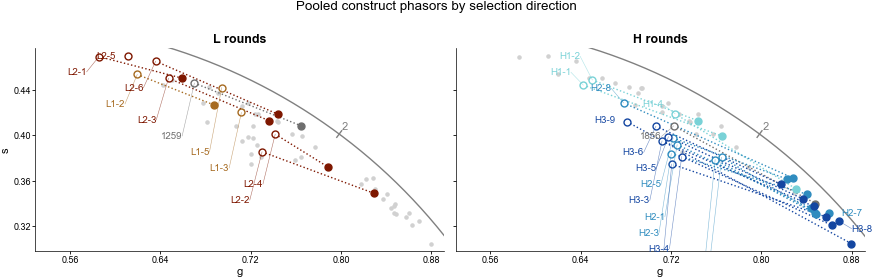

In [5]:
plot_construct_pairs(
    constructs_csv,
    {'L rounds': ['L1', 'L2', '1259'],
     'H rounds': ['H1', 'H2', 'H3', '1856']},
    ncols=2, panel_width=4.4, pad=0.04,
    title="Pooled construct phasors by selection direction",
    name="construct_pairs_groups",
);

### Representative constructs

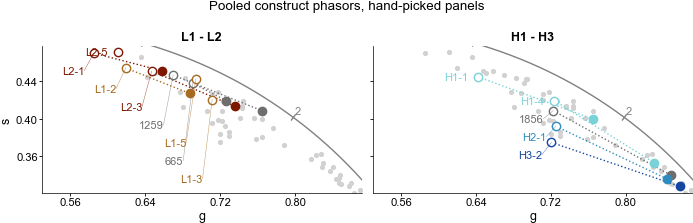

In [6]:
plot_construct_pairs(
    constructs_csv,
    {'L1 - L2': ['L2-1', 'L2-3', 'L2-5', 'L1-2', 'L1-3', 'L1-5', '1259', '665'],
     'H1 - H3': ['H1-1', 'H1-4', 'H2-1', 'H3-2', '1856']},
    ncols=2, panel_width=3.5, pad=0.05, fontsize=8, tick_fontsize=8, markersize=6,
    title="Pooled construct phasors, hand-picked panels",
    name="representative_constructs_grouped",
);

## Dumbbells

One value per construct and compartment, joined by a connector whose length
is the IB - cytosol difference. The axis is laid out by `groups`, with the
group names as bands above it. Marker area reports `size_by` on a log scale,
by default the mean number of photons per object (`photons / n_objects`).

In [7]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"MuPDF's `mutool` is unavailable.*",
    category=RuntimeWarning,
)

METRIC_LABELS = {
    'E_phi':      '$E_\\varphi$',
    'E_m':        '$E_\\mathrm{m}$',
    'tau_phi_ns': '$\\tau_\\varphi$ (ns)',
    'tau_m_ns':   '$\\tau_\\mathrm{m}$ (ns)',
}

SIZE_LABELS = {
    'photons':            'Photons',
    'photons_per_object': 'Photons\nper object',
    'n_objects':          'Objects',
}


def draw_dumbbells(ax, df, value, order, colors, linewidth=0.8, markersize=26,
                   size=None, size_scale=None, edgewidth=0.9):
    """One connector and two markers per construct along the x axis.

    The IB marker is filled and has no outline; the cytosol marker is a ring.
    `size` names the column that sets each marker's area through `size_scale`.
    """
    for i, sample in enumerate(order):
        cell = df[df['sample'] == sample]
        values, areas = {}, {}
        for level in MASK_ORDER:
            found = cell[(cell['mask_type'] == level) & cell[value].notna()]
            if len(found) > 1:
                raise ValueError(f"{sample} / {level}: expected one value, got {len(found)}")
            if len(found) == 1:
                row = found.iloc[0]
                values[level] = float(row[value])
                areas[level] = markersize if size is None else size_scale(row[size])

        color = colors.get(sample, FAMILY_COLOR_FALLBACK)
        if len(values) == 2:
            ax.plot([i, i], [values[MASK_ORDER[0]], values[MASK_ORDER[1]]],
                    color=color, lw=linewidth, zorder=2, solid_capstyle='round')
        for level, y in values.items():
            filled = level == MASK_ORDER[0]
            ax.scatter(i, y, s=areas[level], marker='o',
                       facecolor=color if filled else 'white',
                       edgecolor='none' if filled else color,
                       linewidth=0 if filled else edgewidth, zorder=3)


def dumbbell_legend(ax):
    """Filled/hollow key in neutral grey."""
    handles = [
        plt.Line2D([], [], ls='none', marker='o', markersize=4.5,
                   markerfacecolor=FAMILY_COLOR_FALLBACK if j == 0 else 'white',
                   markeredgecolor='none' if j == 0 else FAMILY_COLOR_FALLBACK,
                   markeredgewidth=0 if j == 0 else 0.9, label=level)
        for j, level in enumerate(MASK_ORDER)
    ]
    return ax.legend(handles=handles)


def log_size_scale(values, size_range=(8, 90), limits=None):
    """Marker areas linear in log10 of a positive column.

    Returns `(scale, limits)`: `scale` maps one value to an area in points**2,
    `limits` is the (low, high) data range mapped onto `size_range`.
    """
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite) & (finite > 0)]
    if limits is None:
        limits = (finite.min(), finite.max()) if len(finite) else (1.0, 10.0)
    low, high = (float(limits[0]), float(limits[1]))
    log_low, log_high = np.log10(low), np.log10(high)
    area_low, area_high = size_range

    def scale(value):
        value = float(value) if value is not None and np.isfinite(value) else 0.0
        if value <= 0 or log_high <= log_low:
            return area_low
        fraction = (np.log10(value) - log_low) / (log_high - log_low)
        return area_low + float(np.clip(fraction, 0, 1)) * (area_high - area_low)

    return scale, (low, high)


def format_count(value):
    """1333468 -> '1.3M'."""
    for cut, suffix in ((1e6, 'M'), (1e3, 'k')):
        if value >= cut:
            mantissa = value / cut
            return f"{mantissa:.{0 if mantissa >= 10 else 1}f}{suffix}"
    return f"{value:.0f}"


def size_legend(ax, scale, limits, n=3, title=None, y=0.72):
    """Key for the marker areas: `n` values spread over the log range, true to scale."""
    ticks = np.logspace(np.log10(limits[0]), np.log10(limits[1]), n)
    exponent = np.floor(np.log10(ticks))
    ticks = np.unique(np.round(ticks / 10 ** exponent) * 10 ** exponent)

    handles = [
        plt.Line2D([], [], ls='none', marker='o',
                   markersize=np.sqrt(scale(tick)),   # scatter sizes are areas
                   markerfacecolor='0.6', markeredgecolor='none',
                   markeredgewidth=0, label=format_count(tick))
        for tick in ticks
    ]
    # markerscale=1: the cnsplots style would draw legend markers at half size.
    return ax.legend(handles=handles, title=title, markerscale=1,
                     labelspacing=1.1, borderpad=0.7, handletextpad=0.9,
                     frameon=False, bbox_to_anchor=(1, y), loc='upper left')


def plot_construct_dumbbell(csv, groups, metric='E_phi', exclude=None,
                            width=760, height=260, markersize=26,
                            linewidth=0.8, label_rotation=45,
                            size_by='photons_per_object', size_range=(8, 90),
                            size_limits=None, size_legend_y=0.72,
                            title=None, name=None, formats=('svg', 'png')):
    """`metric` of IB and cytosol for the constructs named in `groups`.

    `groups` is `{band label: [entries]}`, as for `plot_construct_pairs`.
    `size_by=None` draws every marker at `markersize`. Returns the Axes.
    """
    df = load_constructs(csv)
    exclude = default_exclude(exclude)
    order, bounds = grouped_order(df, groups, exclude)
    if not order:
        print("Nothing to draw: no group matched a construct.")
        return None
    df = df[df['sample'].isin(order)]
    df = df.assign(photons_per_object=df['photons'] / df['n_objects'].replace(0, np.nan))
    colors = {sample: family_color(sample) for sample in order}

    scale, limits = ((None, None) if size_by is None else
                     log_size_scale(df[size_by], size_range, size_limits))

    cns.figure(width=width, height=height)
    ax = plt.gca()

    draw_dumbbells(ax, df, metric, order, colors, markersize=markersize,
                   linewidth=linewidth, size=size_by, size_scale=scale)

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)
    ax.set_xlim(-0.7, len(order) - 0.3)
    ax.set(xlabel='Construct', ylabel=METRIC_LABELS.get(metric, metric))
    if title:
        ax.set_title(title, pad=14)   # clear of the band labels
    cns.setup_ax(ax)

    # After setup_ax, which resets the tick label rotation.
    if label_rotation:
        plt.setp(ax.get_xticklabels(), rotation=label_rotation,
                 ha='right', rotation_mode='anchor')

    # Band separators and labels.
    for _, start, _ in bounds[1:]:
        ax.axvline(start - 0.5, color='0.8', lw=0.6, zorder=0)
    for label, start, end in bounds:
        ax.text((start + end) / 2, 1.01, label, transform=ax.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=6, color='0.35')

    dumbbell_legend(ax)
    cns.take_legend_out('ROI mask', ax=ax)

    if size_by is not None:
        # Keep the mask legend when the size legend is added.
        ax.add_artist(ax.get_legend())
        size_legend(ax, scale, limits, y=size_legend_y,
                    title=SIZE_LABELS.get(size_by, size_by))

    if name:
        for ext in formats:
            cns.savefig(os.path.join(figure_dir, f"{name}.{ext}"))
    plt.show()
    return ax

### $E_\varphi$ by selection round

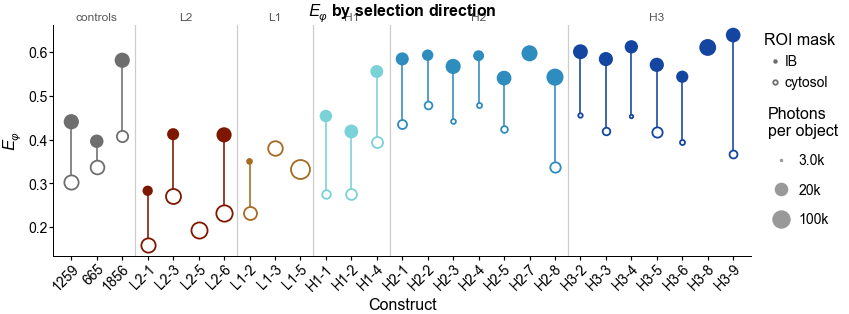

In [8]:
plot_construct_dumbbell(
    constructs_csv,
    groups={'controls': ['1259', '665', '1856'],
            'L2': ['L2-1', 'L2-3', 'L2-5', 'L2-6'],
            'L1': ['L1-2', 'L1-3', 'L1-5'],
            'H1': ['H1-1', 'H1-2', 'H1-4'],
            'H2': ['H2-1', 'H2-2', 'H2-3', 'H2-4', 'H2-5', 'H2-7', 'H2-8'],
            'H3': ['H3-2', 'H3-3', 'H3-4', 'H3-5', 'H3-6', 'H3-8', 'H3-9']},
    metric='E_phi', height=150, width=450, size_range=(3, 90),
    title="$E_\\varphi$ by selection direction",
    name="e_phi_by_construct_dumbbell_selection",
);

### $E_\varphi$ of the reference constructs

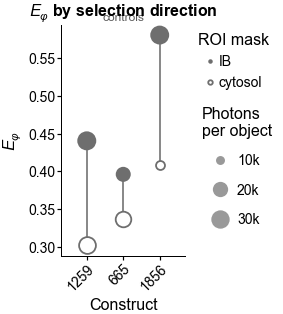

In [9]:
plot_construct_dumbbell(
    constructs_csv,
    groups={'controls': ['1259', '665', '1856']},
    metric='E_phi', height=150, width=80, size_range=(20, 90),
    title="$E_\\varphi$ by selection direction",
    name="e_phi_by_dumbbell_controls",
);